__Лабораторная работа №16__

Необходимо загрузить данные опросов с сайта stackoverflow на 2022 год  

https://insights.stackoverflow.com/survey

и провести исследование данных по аналогии с работой на занятии.   

Попробуйте найти из данных 3 интересных аналитических инсайтов (data insights)

In [1]:
import numpy as np
from numpy import random as rng
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()
np.set_printoptions(precision=2)
pd.set_option('max_colwidth',0)

# загружаем данные

In [2]:
# !wget -c https://info.stackoverflowsolutions.com/rs/719-EMH-566/images/stack-overflow-developer-survey-2022.zip

In [3]:
# !ls -1 data/stack-overflow-developer-survey-2022

----

In [4]:
folder_data = 'data/stack-overflow-developer-survey-2022'

In [5]:
# результаты опросов
survey_results_public = pd.read_csv(folder_data+'/survey_results_public.csv').convert_dtypes()
display(len(survey_results_public))
display(survey_results_public.sample(2))

73268

,ResponseId,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,...,TimeSearching,TimeAnswering,Onboarding,ProfessionalTech,TrueFalse_1,TrueFalse_2,TrueFalse_3,SurveyLength,SurveyEase,ConvertedCompYearly
57399,57400,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Books / Physical media;Other online resources (e.g., videos, blogs, forum);On the job training;Online Courses or Certification",Technical documentation;Blogs;Stack Overflow;Online books;How-to videos;Coding sessions (live or recorded);Certification videos,Udemy,4,...,30-60 minutes a day,60-120 minutes a day,Just right,DevOps function;Microservices;Developer portal or other central places to find tools/services;Continuous integration (CI) and (more often) continuous delivery;Automated testing,Yes,Yes,Yes,Too long,Easy,18056
29548,29549,I am a developer by profession,"Employed, full-time",Fully remote,Hobby;Contribute to open-source projects;Freelance/contract work,"Associate degree (A.A., A.S., etc.)","Books / Physical media;Other online resources (e.g., videos, blogs, forum);School (i.e., University, College, etc);On the job training;Online Courses or Certification","Technical documentation;Blogs;Programming Games;Written Tutorials;Stack Overflow;Online books;Video-based Online Courses;Online challenges (e.g., daily or weekly coding challenges);Online forum;How-to videos;Written-based Online Courses;Auditory material (e.g., podcasts);Interactive tutorial;Coding sessions (live or recorded)",Pluralsight,28,...,30-60 minutes a day,15-30 minutes a day,Very short,Innersource initiative;DevOps function;Continuous integration (CI) and (more often) continuous delivery;Automated testing,No,Yes,Yes,Appropriate in length,Neither easy nor difficult,37325


In [6]:
cols = [
'ResponseId', # номер в базе
'MainBranch', # отношение к программированию 
'Employment', # социальный статус (студент, безработный, фрилансер ...)
'RemoteWork', # удалёнка
'CodingActivities', # загрузка программированием (по работе?)
'EdLevel', # уровень образования
'LearnCode', # источники образования
'LearnCodeOnline',  # источники информации 
'LearnCodeCoursesCert', # дипломы/сертификаты
'YearsCode', # сколько лет программирую
'YearsCodePro',  # сколько лет программирую профессионально 
'DevType', # специализация программирования
'OrgSize', # размер конторы
#'PurchaseInfluence', # ?
'BuyNewTool', # источник информации об инструментах (платных)
'Country', # страна
#'Currency', # валюта
#'CompTotal', # ?
#'CompFreq', # ?
'LanguageHaveWorkedWith', # писал на языках
'LanguageWantToWorkWith', # хотел бы попробовать язык
'DatabaseHaveWorkedWith', # использовал БД
'DatabaseWantToWorkWith', # хотел бы попробовать БД
'PlatformHaveWorkedWith', # использовал платформу (облачную)
'PlatformWantToWorkWith', # хотел бы попробовать платформу
'WebframeHaveWorkedWith', # работал с Web фреймворками
'WebframeWantToWorkWith', # хотел бы попробовать Web фреймворк
'MiscTechHaveWorkedWith', # использовал библиотеки
'MiscTechWantToWorkWith', # хотел бы попробовать библиотеки
'ToolsTechHaveWorkedWith', # использовал инструменты 
'ToolsTechWantToWorkWith', # хотел бы попробовать инструменты
'NEWCollabToolsHaveWorkedWith', # использовал (новые) инструменты совместной разработки
'NEWCollabToolsWantToWorkWith',  # хотел бы попробовать инструменты совместной разработки
'OpSysProfessional use', # использую OS в работе
'OpSysPersonal use', # использую OS в личных целях
'VersionControlSystem', # использую системы контроля версий
#'VCInteraction', # ?
#'VCHostingPersonal use', # ? NULL
#'VCHostingProfessional use', # ? NULL
'OfficeStackAsyncHaveWorkedWith', # использую средства совместной работы над проектом 
'OfficeStackAsyncWantToWorkWith', # хотел бы попробовать средства совместной работы над проектом 
'OfficeStackSyncHaveWorkedWith',  # использую средства коммуникации
'OfficeStackSyncWantToWorkWith', # хотел бы попробовать средства коммуникации
'Blockchain', # отношение к технологии Blockchain
'NEWSOSites', # использую сайты для поиск информации
'SOVisitFreq', # как часто посещаю сайты
'SOAccount', # зарегистрировался на сайтах
#'SOPartFreq', # ?
'SOComm', # пишу коменты на сайтах
'Age', # возраст
'Gender', # пол/ориентация
'Trans', # трансексуал?
'Sexuality', # половая ориентация
'Ethnicity', # цвет кожи
'Accessibility', # инвалидность
'MentalHealth', # психические отклонения/расстройства 
# 'TBranch', # ?
# 'ICorPM', # ?
# 'WorkExp', # ?
# 'Knowledge_1',# ?
# 'Knowledge_2',# ?
# 'Knowledge_3',# ?
# 'Knowledge_4',# ?
# 'Knowledge_5',# ?
# 'Knowledge_6',# ?
# 'Knowledge_7',# ?
# 'Frequency_1',# ?
# 'Frequency_2',# ?
# 'Frequency_3',# ?
'TimeSearching', # сколько трачу времени на поиск по сайту
'TimeAnswering', # сколько трачу времени на ответы на сайте
# 'Onboarding', # ?
'ProfessionalTech', # использую технологии разработки
# 'TrueFalse_1', # ?
# 'TrueFalse_2', # ?
# 'TrueFalse_3', # ?
# 'SurveyLength', # ?
# 'SurveyEase', # ?
# 'ConvertedCompYearly', # ?
]

----

In [7]:
survey_results_public['MainBranch'].drop_duplicates()

0     None of these                                                                
1     I am a developer by profession                                               
2     I am not primarily a developer, but I write code sometimes as part of my work
6     I code primarily as a hobby                                                  
19    I am learning to code                                                        
72    I used to be a developer by profession, but no longer am                     
Name: MainBranch, dtype: string

будем рассматривать только тех,  
для кого программирование основная профессия

In [8]:
# # будем рассматривать только тех,
# # для кого программирование основная профессия

# display(len(survey_results_public))

# survey_results_public = survey_results_public[
#         survey_results_public['MainBranch'].isin([
#             'I am a developer by profession',
#             'I am not primarily a developer, but I write code sometimes as part of my work',
#         ])
#     ].reset_index(drop=True)

# display(len(survey_results_public))

In [9]:
# общее количество опрошенных
response_count = survey_results_public['ResponseId'].drop_duplicates().size
display(response_count)

73268

---

In [10]:
def build_count_table(c,df=survey_results_public,drop_words=[]):
    cc = c+'_'
    df_count = df[[cc,'ResponseId']].copy().explode(column=cc)
    df_count[cc] = df_count[cc].apply( lambda s: 'NA' if s in drop_words else s )
    response_count = df['ResponseId'].unique().size
    df_count  = (   
           df_count
            .groupby(cc)
            ['ResponseId']
            .count()
            .reset_index()
            .rename(columns={cc:c,'ResponseId':'response_count'})
            .convert_dtypes()
            .set_index(c)
        )
    df_count = df_count[~df_count.index.isin(['NA',])]
    df_count['part'] = round( (df_count['response_count']/response_count) * 100., 2 ) 
    return df_count 

In [11]:
def plot_bar(ds,title,ax=None,figsize=None):
    ax = ds.plot.barh(figsize=figsize, legend=False, ax=ax) 
    ax.set_title(title, fontsize=12)
    ax.bar_label(ax.containers[0])
    ax.spines['right'].set_visible(False)
    ax.set(ylabel=None)
    return ax

In [12]:
def plot_bar_nlargest(df,title,n=7,ax=None,figsize=None):
    return plot_bar(
        df.nlargest(n=n).sort_values(ascending=True )
        ,title=title
        ,ax=ax
        ,figsize=figsize
    )

In [13]:
def plot_bar_nsmallest(df,title,n=7,ax=None,figsize=None):
    return plot_bar(
        df.nsmallest(n=n).sort_values(ascending=False )
        ,title=title
        ,ax=ax
        ,figsize=figsize
    )

# техническая информация

## языки программирования

In [14]:
# нормализация списка используемых языков программирования
survey_results_public['LanguageHaveWorkedWith_'] = (
        survey_results_public['LanguageHaveWorkedWith']
        .fillna('NA')
        .str.replace('LanguageHaveWorkedWith','NA')
        .str.split(';')
    )

In [15]:
prog_lang = build_count_table(c='LanguageHaveWorkedWith',)
# display(prog_lang)

<Axes: title={'center': 'ТОП языков программирования (%)'}>

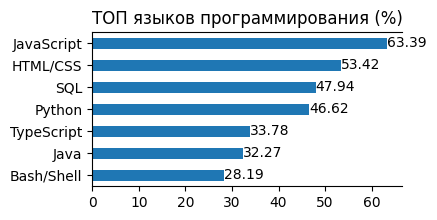

In [16]:
plot_bar_nlargest(prog_lang['part'],title=f'ТОП языков программирования (%)',figsize=(4,2))

## специализация

In [17]:
# (
# survey_results_public['DevType']
# .dropna()
# .drop_duplicates()
# .str.split(';')
# .explode()
# .drop_duplicates()
# .sort_values()   
# )

In [18]:
survey_results_public['DevType_'] = (
        survey_results_public['DevType']
          .fillna('NA')           
          .str.replace('Other (please specify):','NA') 
          .str.replace('Student','NA') 
          .str.replace('Academic researcher','Scientist')
          .str.split(';')
    )

In [19]:
dev_type = build_count_table(c='DevType') 

<Axes: title={'center': 'специализация (%)'}>

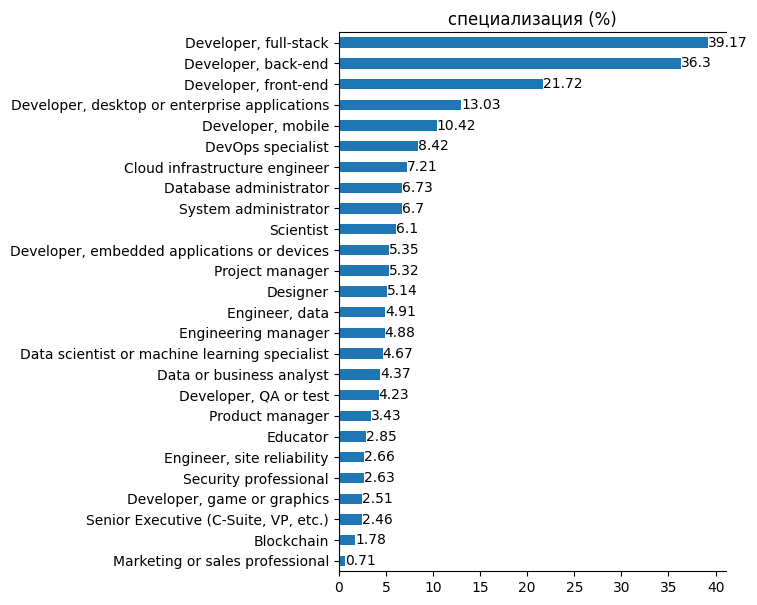

In [20]:
plot_bar( dev_type['part'].sort_values(), title='специализация (%)',figsize=(5,7) )

## операционные системы

In [21]:
survey_results_public['OpSysProfessional use_'] = (
        survey_results_public['OpSysProfessional use']
        .fillna('NA')
        .str.replace('Other (please specify):','NA')
        .str.split(';')
    )

os_prof = build_count_table(c='OpSysProfessional use')

In [22]:
survey_results_public['OpSysPersonal use_'] = (
        survey_results_public['OpSysPersonal use']
        .fillna('NA')
        .str.replace('Other (please specify):','NA')
        .str.split(';')
    )

os_pers = build_count_table(c='OpSysPersonal use')

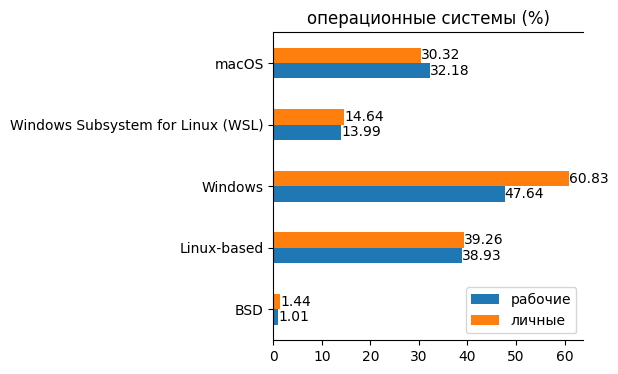

In [23]:
ax = (
    os_prof.join( 
        os_pers
        .rename(columns={'response_count':'response_count_p','part':'part_p',}) 
    )[['part','part_p']]
    .rename(columns={'part_p':'личные','part':'рабочие',}) 
    .plot.barh(figsize=(4,4))
)
ax.set_title('операционные системы (%)')
for c in ax.containers: ax.bar_label(c)
ax.spines['right'].set_visible(False)
ax.set(ylabel=None)
ax.legend(loc='lower right')

## базы данных

In [24]:
# (
#     survey_results_public['DatabaseHaveWorkedWith']
#     .drop_duplicates()
#     .fillna('NA')
#     .str.replace('Other (please specify):','NA')
#     .str.split(';')
#     .explode() 
#     .drop_duplicates()
# )

<Axes: title={'center': 'базы данных (%)'}>

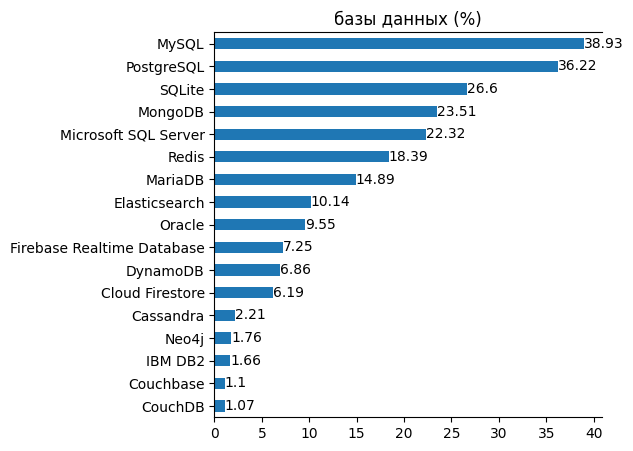

In [25]:
survey_results_public['DatabaseHaveWorkedWith_'] = (
        survey_results_public['DatabaseHaveWorkedWith']
        .fillna('NA')
        .str.replace('Other (please specify):','NA')
        .str.split(';')
    )

db = build_count_table(c='DatabaseHaveWorkedWith')
plot_bar( db['part'].sort_values(), title='базы данных (%)',figsize=(5,5) )

# персональная информация

## возраст участников опроса

In [26]:
survey_results_public['Age_'] = (
        survey_results_public['Age']
          .fillna('NA')
          .str.replace('Prefer not to say','NA') 
          .str.replace(' years old','') 
          .str.replace(' years or older','+') 
          .str.replace('Under ','-') 
    )

In [27]:
age = build_count_table(c='Age')

In [28]:
age_idx = [ '-18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', ]
age = age.loc[age_idx[::-1],:]

<Axes: title={'center': 'возраст участников опроса (%)'}>

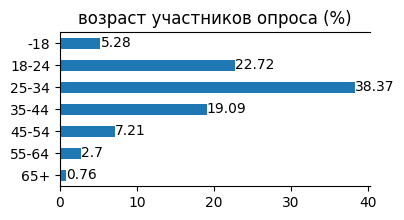

In [29]:
plot_bar( age['part'], title='возраст участников опроса (%)',figsize=(4,2) )

## страна

In [30]:
survey_results_public['Country_'] = ( 
        survey_results_public['Country']
    )

In [31]:
countries = build_count_table(c='Country',)

<Axes: title={'center': 'ТОП активных стран (%)'}>

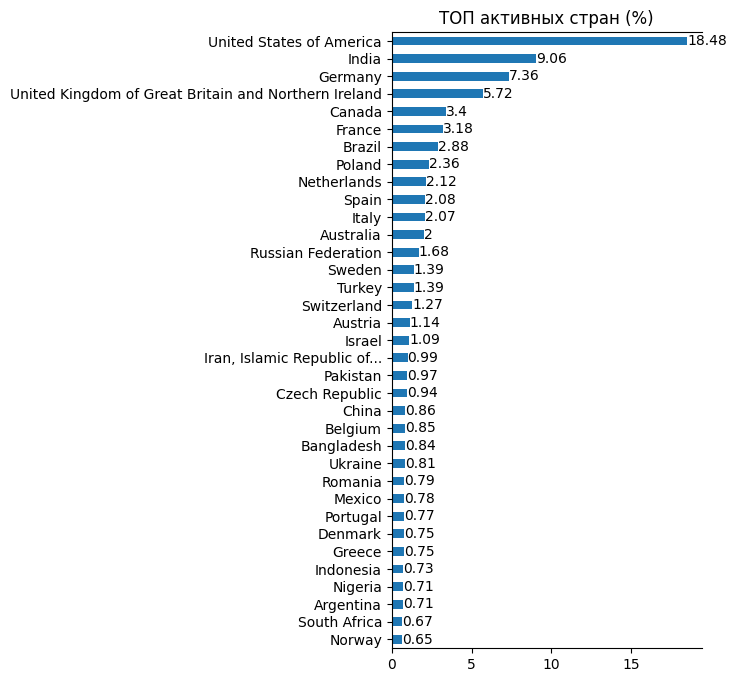

In [32]:
plot_bar_nlargest(countries['part'],title=f'ТОП активных стран (%)',figsize=(4,8),n= 35)

<Axes: title={'center': 'наименее активные страны'}>

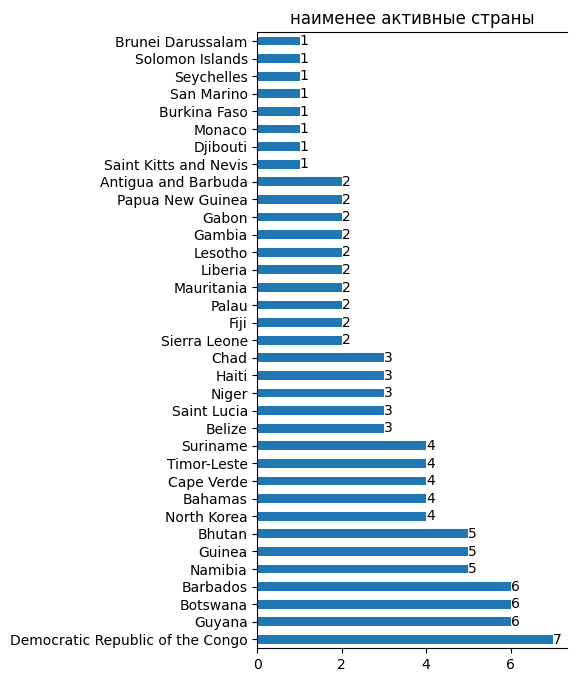

In [33]:
plot_bar_nsmallest(countries['response_count'],title=f'наименее активные страны',figsize=(4,8),n=35)

## этнический состав

In [34]:
# import re

# (
# survey_results_public['Ethnicity']
# .drop_duplicates()
# .str.split(';')
# .explode() 
# .fillna('NA')
# .str.strip()    
# .str.replace('Or, in your own words:','NA')
# .str.replace("I don't know",'NA')
# .str.replace('Prefer not to say','NA')
# .str.replace('Ethnoreligious group','NA')  
# .str.replace('Indigenous (such as Native American or Indigenous Australian)','Indigenous')
# .str.replace('Biracial','Multiracial')
# .apply(lambda s: re.sub(r'^(White|North American|European)$','White/European',s ))
# .apply(lambda s: re.sub(r'^(Black|African)$','Black/African',s ))
# .apply(lambda s: re.sub(r'^(Black|African)$','Black/African',s ))
# .apply(lambda s: re.sub(r'^(Central Asian|East Asian|South Asian|Southeast Asian)','Asian',s))   
# .apply(lambda s: re.sub(r'^(South American|Central American|Hispanic or Latino/a|Caribbean)','Latin',s))    
# .str.replace('North African','Middle Eastern')
# .drop_duplicates() 
# .sort_values()
# )  

<Axes: title={'center': 'этнические группы (%)'}>

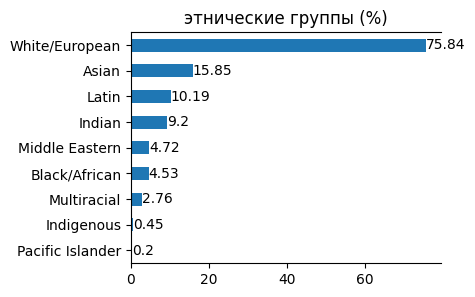

In [35]:
import re

survey_results_public['Ethnicity_'] = ( 
        survey_results_public['Ethnicity']
        .fillna('NA')
        .str.replace('Or, in your own words:','NA')
        .str.replace("I don't know",'NA')
        .str.replace('Prefer not to say','NA')
        .str.replace('Ethnoreligious group','NA')  
        .str.replace('Indigenous (such as Native American or Indigenous Australian)','Indigenous')
        .str.replace('Biracial','Multiracial')
        .str.replace('North African','Middle Eastern')    
        .str.split(';')
        .apply(lambda s: [ w.strip() for w in s ] )   
    
        .apply(lambda s: [ re.sub(r'^(White|North American|European)$','White/European',w )  for w in s ] )
        .apply(lambda s: [ re.sub(r'^(Black|African)$','Black/African',w )  for w in s ] )
        .apply(lambda s: [ re.sub(r'^(Black|African)$','Black/African',w )  for w in s ] )
        .apply(lambda s: [ re.sub(r'^(Central Asian|East Asian|South Asian|Southeast Asian)','Asian',w) 
                           for w in s ] )
        .apply(lambda s: [ re.sub(r'^(South American|Central American|Hispanic or Latino/a|Caribbean)','Latin',w)
                           for w in s ])
    
    )

ethnicity = build_count_table(c='Ethnicity',)

plot_bar(ethnicity['part'].sort_values(),title=f'этнические группы (%)',figsize=(4,3))

## пол и ориентация участников опроса

### пол

In [36]:
# (
# survey_results_public['Gender']
# .drop_duplicates()
# .fillna('NA')
# .str.split(';')
# .explode()
# .str.replace('Prefer not to say','NA')    
# .str.replace('Or, in your own words:','NA')    
# .drop_duplicates()    
# )

In [37]:
# нормализация пола
survey_results_public['Gender_'] = (
    survey_results_public['Gender']
      .fillna('NA')
      .str.replace('Prefer not to say','NA')    
      .str.replace('Or, in your own words:','NA')   
      .str.replace('Non-binary, genderqueer, or gender non-conforming','P')   
      .str.split(';')
)

In [38]:
# (
#     survey_results_public['Gender_']
#     .drop_duplicates()
# )

In [39]:
survey_results_public['Sexuality_'] =  (
    survey_results_public['Gender_']
    .apply(lambda s: 'P' if 'P' in s else None )
)

In [40]:
survey_results_public['Gender_'] = (
    survey_results_public['Gender_']
    .apply(lambda s: 
           'Man' if (('Man' in s) and ('Woman' not in s))  
           else 'Woman' if (('Man' not in s) and ('Woman' in s))
           else None
          )
)

### ориентация

In [41]:
# (
# survey_results_public['Sexuality']
# .drop_duplicates()
# .fillna('NA')
# .str.split(';')
# .explode()
# .str.replace('Prefer not to say','NA')    
# .str.replace('Prefer to self-describe:','NA')    
# .drop_duplicates()    
# )

In [42]:
# нормализация пола
survey_results_public['Sexuality__'] = (
    survey_results_public['Sexuality']
      .fillna('NA')
      .str.replace('Prefer not to say','NA')    
      .str.replace('Prefer to self-describe:','NA')    
      .str.replace('Bisexual','P')  
      .str.replace('Gay or Lesbian','P')  
      .str.replace('Queer','P')  
      .str.replace('Straight / Heterosexual','N')  
      .str.split(';')
      .apply(lambda s: 'P' if 'P' in s else 'N' if 'N' in s else None )
)

In [43]:
# survey_results_public['Sexuality__'].drop_duplicates()

In [44]:
survey_results_public['Sexuality_'] = (
    survey_results_public['Sexuality_']
    .fillna(survey_results_public['Sexuality__'])
)

In [45]:
# survey_results_public[['Gender_','Sexuality_',]].drop_duplicates()

---

In [46]:
gender = build_count_table(c='Gender')
sexuality = build_count_table(c='Sexuality')

<Axes: title={'center': 'пол участников опроса (%)'}>

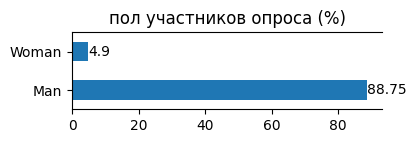

In [47]:
plot_bar( gender['part'], title='пол участников опроса (%)',figsize=(4,1) )

<Axes: title={'center': 'ориентация участников опроса (%)'}>

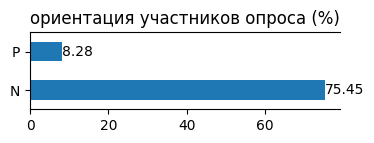

In [48]:
plot_bar( sexuality['part'], title='ориентация участников опроса (%)',figsize=(4,1) )

## психические отклонения/расстройства 

<Axes: title={'center': 'психические отклонения/расстройства (%)'}>

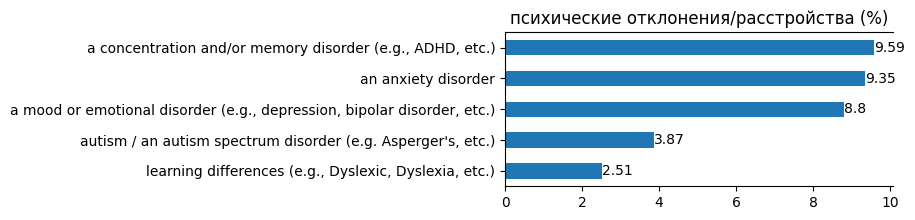

In [49]:
survey_results_public['MentalHealth_'] = (
        survey_results_public['MentalHealth']
          .fillna('NA')
          .str.replace('I have ','')
          .str.replace('Or, in your own words:','NA')
          .str.replace('None of the above','NA')
          .str.replace('Prefer not to say','NA')
          .str.split(';')
    )

mental_health = build_count_table(c='MentalHealth',)

plot_bar( mental_health['part'].sort_values(), title='психические отклонения/расстройства (%)',figsize=(5,2) )

## инвалидность 

In [50]:
# (
# survey_results_public['Accessibility']
# .drop_duplicates()
# .str.split(';')
# .explode() 
# .fillna('NA')
# .str.replace('Or, in your own words:','NA')
# .str.replace('None of the above','NA')
# .str.replace('Prefer not to say','NA')
# .str.replace('I am unable to / find it ','')
# .str.replace('I am ','')
# .drop_duplicates() 
# ) 

<Axes: title={'center': 'инвалидность (%)'}>

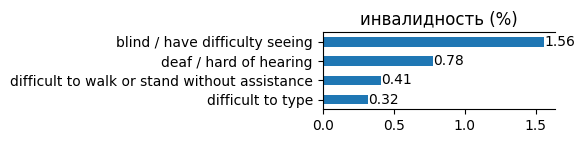

In [51]:
survey_results_public['Accessibility_'] = (
        survey_results_public['Accessibility']
        .fillna('NA')
        .str.replace('Something else', 'NA')
        .str.replace('Or, in your own words:','NA')
        .str.replace('None of the above','NA')
        .str.replace('Prefer not to say','NA')
        .str.replace('I am unable to / find it ','')
        .str.replace('I am ','')
        .str.split(';')
    )

accessibility = build_count_table(c='Accessibility',)

plot_bar( accessibility['part'].sort_values(), title='инвалидность (%)',figsize=(3,1) )

## уровень образования

In [52]:
# (  # уровень образования
# survey_results_public['EdLevel']
# .drop_duplicates()
# .fillna('NA')
# .str.replace('Something else', 'NA')
# .drop_duplicates() 

# ) 

<Axes: title={'center': ' уровень образования (%)'}>

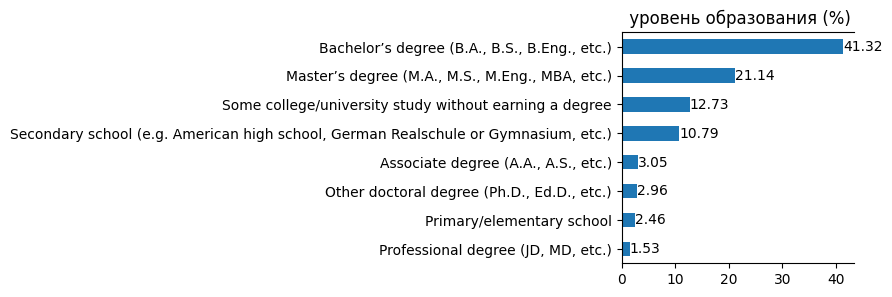

In [53]:
survey_results_public['EdLevel_'] = (
        survey_results_public['EdLevel']
          .fillna('NA')
          .str.replace('Something else', 'NA')
          .str.split(';')
    )

edu_level = build_count_table(c='EdLevel',)

plot_bar( edu_level['part'].sort_values(), title=' уровень образования (%)',figsize=(3,3) )

## удалённая работа

<Axes: title={'center': 'удалённая работа (%)'}>

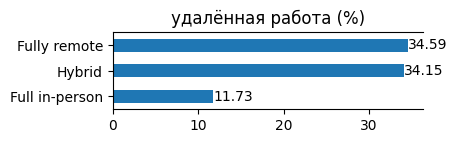

In [54]:
survey_results_public['RemoteWork_'] = (
        survey_results_public['RemoteWork']
          .fillna('NA')
          .str.replace('Hybrid (some remote, some in-person)','Hybrid')
    )

remote_work = build_count_table(c='RemoteWork')

plot_bar( remote_work['part'].sort_values(), title='удалённая работа (%)',figsize=(4,1) )

## размер конторы

In [55]:
survey_results_public['OrgSize_'] = (
        survey_results_public['OrgSize']
          .fillna('NA')
          .str.replace('I don’t know','NA')
          .str.replace('Just me - I am a freelancer, sole proprietor, etc.','NA')
          .str.replace(' employees','')
    )

In [56]:
org_size = build_count_table(c='OrgSize')
org_size_idx = [
 '2 to 9',
 '10 to 19',
 '20 to 99',
 '100 to 499',
 '500 to 999',
 '1,000 to 4,999',
 '5,000 to 9,999',
 '10,000 or more',
]

org_size = org_size.loc[org_size_idx]
# display(org_size)

<Axes: title={'center': 'размер конторы (%)'}>

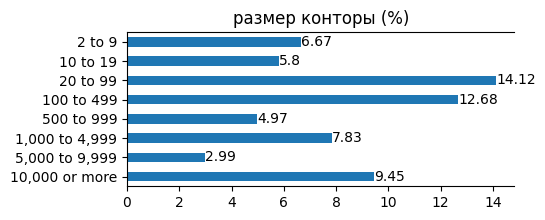

In [57]:
plot_bar( org_size.loc[org_size_idx[::-1],'part'], title='размер конторы (%)',figsize=(5,2) )

# комбинации полей

In [58]:
def build_count_2_table(c0,c1,df=survey_results_public,na_cols=[]):
    cc0 = c0+'_'
    cc1 = c1+'_'
    
    df_count = df[[cc0,cc1,'ResponseId']].copy().explode(column=cc0).explode(column=cc1)
    df_count[cc0] = df_count[cc0].apply( lambda s: 'NA' if s in na_cols else s )
    df_count[cc1] = df_count[cc1].apply( lambda s: 'NA' if s in na_cols else s )

    return (
        df_count
        .query( f'{cc0}!="NA"' )
        .query( f'{cc1}!="NA"' )
        .groupby(by=[cc0,cc1])
        ['ResponseId']
        .count()
        .reset_index()
        .rename(columns={cc0:c0,cc1:c1,'ResponseId':'count'})
    )

##  языки программирования и страна 

In [59]:
top_countries_idx = countries.nlargest(columns='part',n=35).index
top_countries_idx

Index(['United States of America', 'India', 'Germany',
       'United Kingdom of Great Britain and Northern Ireland', 'Canada',
       'France', 'Brazil', 'Poland', 'Netherlands', 'Spain', 'Italy',
       'Australia', 'Russian Federation', 'Sweden', 'Turkey', 'Switzerland',
       'Austria', 'Israel', 'Iran, Islamic Republic of...', 'Pakistan',
       'Czech Republic', 'China', 'Belgium', 'Bangladesh', 'Ukraine',
       'Romania', 'Mexico', 'Portugal', 'Denmark', 'Greece', 'Indonesia',
       'Argentina', 'Nigeria', 'South Africa', 'Norway'],
      dtype='string', name='Country')

In [60]:
prog_lang_idx = prog_lang.nlargest(columns='part',n=25).index

In [61]:
prog_lang_idx[:5] # ТОП5 языков

Index(['JavaScript', 'HTML/CSS', 'SQL', 'Python', 'TypeScript'], dtype='string', name='LanguageHaveWorkedWith')

In [62]:
prog_lang_idx = prog_lang_idx[5:] # остальные языки
prog_lang_idx

Index(['Java', 'Bash/Shell', 'C#', 'C++', 'PHP', 'C', 'PowerShell', 'Go',
       'Rust', 'Kotlin', 'Dart', 'Ruby', 'Assembly', 'Swift', 'R', 'VBA',
       'MATLAB', 'Lua', 'Groovy', 'Delphi'],
      dtype='string', name='LanguageHaveWorkedWith')

In [63]:
# популярные языки (исключая ТОП5) по странам
df = (
        build_count_2_table(c0='Country',c1='LanguageHaveWorkedWith')
        .merge(countries,on='Country',how='left')
    )

df['part'] = ( df['count']/ df['response_count'] ).apply(lambda x: round( x*100.,2 ) )
df = ( 
        df[['Country','LanguageHaveWorkedWith','part']]
       .pivot(index='LanguageHaveWorkedWith', columns='Country', values='part')
       .fillna(0.)
    )

pd.DataFrame({
    'lang':[ 
         ';   '.join(   
             df.loc[prog_lang_idx,c].nlargest(n=2)
                 .sort_values(ascending=False)
                 .reset_index()
                 .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
                 .tolist()
         )
         for c in top_countries_idx 
        ],
    }
    ,index=top_countries_idx
)

# df.loc[prog_lang_idx].T.loc[top_countries_idx].idxmax(axis=1).to_frame()

,lang
Country,
United States of America,Bash/Shell(38.93%); Java(30.07%)
India,Java(37.67%); C++(26.1%)
Germany,Java(41.22%); Bash/Shell(35.68%)
United Kingdom of Great Britain and Northern Ireland,Bash/Shell(33.89%); C#(32.84%)
Canada,Bash/Shell(35.54%); Java(29.88%)
France,Java(36.6%); Bash/Shell(36.51%)
Brazil,Java(30.06%); Bash/Shell(23.85%)
Poland,Bash/Shell(30.66%); C#(30.31%)
Netherlands,C#(33.25%); Java(30.87%)


## специализация по странам

In [64]:
# ТОП5 специализаций
top_spec = list( dev_type.nlargest(n=6,columns='response_count').index )
top_spec

['Developer, full-stack',
 'Developer, back-end',
 'Developer, front-end',
 'Developer, desktop or enterprise applications',
 'Developer, mobile',
 'DevOps specialist']

In [65]:
 # остальные специализации
other_spec = list( dev_type[~dev_type.index.isin(top_spec)].index )
other_spec

['Blockchain',
 'Cloud infrastructure engineer',
 'Data or business analyst',
 'Data scientist or machine learning specialist',
 'Database administrator',
 'Designer',
 'Developer, QA or test',
 'Developer, embedded applications or devices',
 'Developer, game or graphics',
 'Educator',
 'Engineer, data',
 'Engineer, site reliability',
 'Engineering manager',
 'Marketing or sales professional',
 'Product manager',
 'Project manager',
 'Scientist',
 'Security professional',
 'Senior Executive (C-Suite, VP, etc.)',
 'System administrator']

In [66]:
# популярные специализации (исключая ТОП5) по странам 
df = (
        build_count_2_table(c0='Country',c1='DevType')
        .merge(countries,on='Country',how='left')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['DevType','Country','part']]
       .pivot(index='Country', columns='DevType', values='part')
       .fillna(0.)
    ).T

# df

In [67]:
# df[other_spec].loc[top_countries_idx].idxmax(axis=1).to_frame()

pd.DataFrame({
    'dev':[ 
         ';   '.join(   
             df.loc[other_spec,c].nlargest(n=2)
                 .sort_values(ascending=False)
                 .reset_index()
                 .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
                 .tolist()
         )
         for c in top_countries_idx 
        ],
    }
    ,index=top_countries_idx
)

,dev
Country,
United States of America,Cloud infrastructure engineer(9.59%); System administrator(7.88%)
India,Cloud infrastructure engineer(4.84%); Designer(4.43%)
Germany,Scientist(10.14%); System administrator(9.62%)
United Kingdom of Great Britain and Northern Ireland,Cloud infrastructure engineer(8.4%); Database administrator(6.97%)
Canada,Cloud infrastructure engineer(8.63%); Database administrator(6.51%)
France,Scientist(8.55%); System administrator(7.69%)
Brazil,Scientist(7.82%); Cloud infrastructure engineer(7.4%)
Poland,"Cloud infrastructure engineer(7.27%); Developer, embedded applications or devices(6.12%)"
Netherlands,Cloud infrastructure engineer(8.49%); Scientist(6.88%)


## языки программирования и пол

In [68]:
df = (
        build_count_2_table(c0='Gender',c1='LanguageHaveWorkedWith')
        .merge(gender,on='Gender',how='left')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['Gender','LanguageHaveWorkedWith','part']]
       .pivot(index='LanguageHaveWorkedWith', columns='Gender', values='part')
    )

# df

<Axes: >

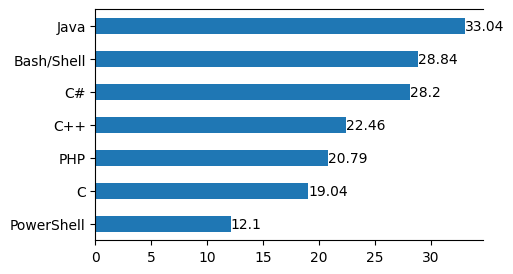

In [69]:
# популярные языки (исключая ТОП5) мальчики
plot_bar_nlargest(df.loc[prog_lang_idx]['Man'],title='',figsize=(5,3))

<Axes: >

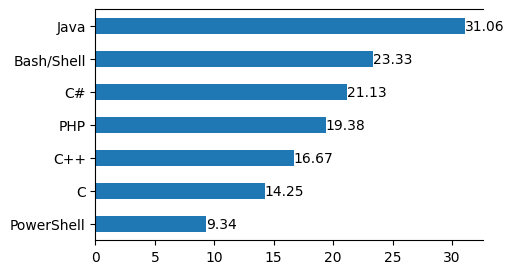

In [70]:
# популярные языки (исключая ТОП5) девочки
plot_bar_nlargest(df.loc[prog_lang_idx]['Woman'],title='',figsize=(5,3))

## языки программирования и возраст

In [71]:
df = (
        build_count_2_table(c0='Age',c1='LanguageHaveWorkedWith')
        .merge(age,on='Age',how='left')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )
df = ( 
        df[['Age','LanguageHaveWorkedWith','part']]
       .pivot(index='LanguageHaveWorkedWith', columns='Age', values='part')
        [age_idx]
    )

In [72]:
def plot_table(df,title):
    display(
        df.fillna(0)
        .style
        .background_gradient(
            axis=1, 
            vmin=1., 
            vmax=df.max().max()+1, 
            cmap='rainbow'
        )
        .format( lambda v: f'{v:.1f}%' if v>0. else '') 
        .set_caption(f'<b><font size=+1>{title}</font></b>',)
    )    

In [73]:
plot_table(df[age_idx][df.max(axis=1)>10.],title='языки и возраст')

Age,-18,18-24,25-34,35-44,45-54,55-64,65+
LanguageHaveWorkedWith,,,,,,,
Bash/Shell,25.0%,26.7%,27.8%,33.4%,32.5%,28.0%,19.7%
C,26.8%,31.7%,13.8%,12.2%,17.0%,21.7%,21.8%
C#,29.8%,27.0%,26.1%,29.5%,33.7%,28.2%,23.1%
C++,36.1%,34.3%,17.2%,15.5%,18.5%,23.6%,20.8%
Dart,7.9%,10.7%,6.0%,3.9%,3.3%,2.5%,2.4%
Delphi,0.4%,0.7%,1.0%,4.0%,13.4%,21.4%,25.3%
Go,10.8%,10.8%,11.7%,11.8%,8.8%,7.1%,4.0%
HTML/CSS,67.6%,62.0%,53.3%,50.7%,47.1%,40.2%,31.9%
Java,36.3%,43.1%,30.8%,28.9%,26.6%,23.4%,18.2%


In [74]:
del df

## языки программирования и специализация

In [75]:
df = (
        build_count_2_table(c0='DevType',c1='LanguageHaveWorkedWith')
        .merge(dev_type,on='DevType',how='left')
    )

df['part'] = ( df['count']/ df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['DevType','LanguageHaveWorkedWith','part']]
       .pivot(index='LanguageHaveWorkedWith', columns='DevType', values='part')
    )
# df

In [76]:
# prog_lang_idx

In [77]:
# наиболее популярные языки по специализациям

# df.T.idxmax(axis=1).to_frame() 

pd.DataFrame({
    'lang':[ 
         ';   '.join(   
             df[c].nlargest(n=2)
                 .sort_values(ascending=False)
                 .reset_index()
                 .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
                 .tolist()
         )
         for c in other_spec 
        ],
    }
    ,index=other_spec
)

,lang
Blockchain,JavaScript(73.58%); HTML/CSS(54.61%)
Cloud infrastructure engineer,JavaScript(69.18%); SQL(60.0%)
Data or business analyst,SQL(74.45%); Python(60.32%)
Data scientist or machine learning specialist,Python(86.89%); SQL(57.54%)
Database administrator,SQL(79.81%); JavaScript(73.9%)
Designer,JavaScript(77.15%); HTML/CSS(71.94%)
"Developer, QA or test",JavaScript(73.06%); SQL(62.73%)
"Developer, embedded applications or devices",Python(57.79%); C++(55.44%)
"Developer, game or graphics",JavaScript(63.09%); HTML/CSS(54.44%)
Educator,JavaScript(67.56%); HTML/CSS(61.63%)


## возраст и специализация

In [78]:
df = (
        build_count_2_table(c0='DevType',c1='Age')
        .merge(dev_type,on='DevType',how='left')
    )

df['part'] = ( df['count']/ df['response_count']).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['DevType','Age','part']]
       .pivot(index='Age', columns='DevType', values='part')
    ).T

In [79]:
# df

In [80]:
# популярные специализации по возрастам

# df.loc[age_idx,other_spec].idxmax(axis=1).to_frame()

pd.DataFrame({
    'dev':[ 
         ';   '.join(   
         df[c].nlargest(n=2)
             .sort_values(ascending=False)
             .reset_index()
             .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
             .tolist()
         )
         for c in age_idx 
        ],
    }
    ,index=age_idx
)

,dev
-18,"Developer, game or graphics(5.44%); Designer(3.24%)"
18-24,"Blockchain(24.96%); Developer, game or graphics(20.79%)"
25-34,"Data scientist or machine learning specialist(46.29%); Engineer, data(45.69%)"
35-44,"Engineering manager(39.48%); Senior Executive (C-Suite, VP, etc.)(34.79%)"
45-54,"Senior Executive (C-Suite, VP, etc.)(19.89%); Product manager(15.51%)"
55-64,"Designer(8.0%); Senior Executive (C-Suite, VP, etc.)(7.98%)"
65+,"Senior Executive (C-Suite, VP, etc.)(2.33%); Designer(2.05%)"


## пол и специализация

In [81]:
df = (
        build_count_2_table(c0='DevType',c1='Gender',na_cols=['All','NA','Student','Educator'])
        .merge(dev_type,on='DevType',how='left')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['DevType','Gender','part']]
       .pivot(index='Gender', columns='DevType', values='part')
    ).T

In [82]:
pd.DataFrame({
    'dev':[ 
         ';   '.join(   
         df[c].nlargest(n=3)
             .sort_values(ascending=False)
             .reset_index()
             .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
             .tolist()
         )
         for c in gender.index 
        ],
    }
    ,index=gender.index
)

,dev
Gender,
Man,"Developer, desktop or enterprise applications(93.69%); DevOps specialist(93.61%); Cloud infrastructure engineer(93.56%)"
Woman,"Marketing or sales professional(8.11%); Developer, front-end(5.16%); Developer, QA or test(5.14%)"


In [83]:
del df

##  специализация и психические отклонения 

In [84]:
df = (
        build_count_2_table(c0='MentalHealth',c1='DevType',na_cols=
          ['None of the above','Prefer not to say','Or, in your own words:']
        )
        .merge(dev_type,on='DevType',how='inner')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['MentalHealth','DevType','part']]
       .pivot(index='DevType', columns='MentalHealth', values='part')
    )

# df

In [85]:
pd.DataFrame({
    'dev':[ 
         ';   '.join(   
         df[c].nlargest(n=3)
             .sort_values(ascending=False)
             .reset_index()
             .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
             .tolist()
         )
         for c in mental_health.index 
        ],
    }
    ,index=mental_health.index
)

,dev
MentalHealth,
"a concentration and/or memory disorder (e.g., ADHD, etc.)","Marketing or sales professional(17.76%); Engineer, site reliability(16.69%); Developer, game or graphics(14.64%)"
"a mood or emotional disorder (e.g., depression, bipolar disorder, etc.)","Marketing or sales professional(14.48%); Security professional(14.37%); Developer, QA or test(12.53%)"
an anxiety disorder,"Marketing or sales professional(14.29%); Engineer, site reliability(12.28%); Security professional(12.19%)"
"autism / an autism spectrum disorder (e.g. Asperger's, etc.)","Security professional(8.61%); Engineer, site reliability(7.55%); Marketing or sales professional(7.34%)"
"learning differences (e.g., Dyslexic, Dyslexia, etc.)","Marketing or sales professional(7.53%); Developer, game or graphics(5.28%); Educator(4.88%)"


##  специализация и половая ориентация

In [86]:
df = (
        build_count_2_table(c0='Sexuality',c1='DevType', )
        .merge(dev_type,on='DevType',how='inner')
    )

df['part'] = ( df['count']/df['response_count'] ).apply(lambda x: round( x*100.,2 ) )

df = ( 
        df[['Sexuality','DevType','part']]
       .pivot(index='DevType', columns='Sexuality', values='part')
    )

# df

In [87]:
pd.DataFrame({
    'dev':[ 
         ';   '.join(   
         df[c].nlargest(n=3)
             .sort_values(ascending=False)
             .reset_index()
             .apply(lambda r: f'{r[0]}({r[1]}%)',axis=1)
             .tolist()
         )
         for c in sexuality.index 
        ],
    }
    ,index=sexuality.index
)

,dev
Sexuality,
N,"Engineering manager(81.73%); Senior Executive (C-Suite, VP, etc.)(80.17%); DevOps specialist(80.0%)"
P,"Marketing or sales professional(14.67%); Developer, game or graphics(12.03%); Scientist(10.76%)"
